In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [42]:
df = pd.read_csv("PJM_Load_hourly.csv")
print(df.head())
print(df.info())
print(df.shape)

              Datetime  PJM_Load_MW
0  1998-12-31 01:00:00      29309.0
1  1998-12-31 02:00:00      28236.0
2  1998-12-31 03:00:00      27692.0
3  1998-12-31 04:00:00      27596.0
4  1998-12-31 05:00:00      27888.0
<class 'pandas.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  str    
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), str(1)
memory usage: 514.1 KB
None
(32896, 2)


In [43]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df["Datetime"]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     32896 non-null  datetime64[us]
 1   PJM_Load_MW  32896 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 514.1 KB


In [44]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.sort_values(by='Datetime', ascending=True).head())
print(df.head(10))

Datetime       0
PJM_Load_MW    0
dtype: int64
0
                Datetime  PJM_Load_MW
6574 1998-04-01 01:00:00      22259.0
6575 1998-04-01 02:00:00      21244.0
6576 1998-04-01 03:00:00      20651.0
6577 1998-04-01 04:00:00      20421.0
6578 1998-04-01 05:00:00      20713.0
             Datetime  PJM_Load_MW
0 1998-12-31 01:00:00      29309.0
1 1998-12-31 02:00:00      28236.0
2 1998-12-31 03:00:00      27692.0
3 1998-12-31 04:00:00      27596.0
4 1998-12-31 05:00:00      27888.0
5 1998-12-31 06:00:00      29382.0
6 1998-12-31 07:00:00      31373.0
7 1998-12-31 08:00:00      33272.0
8 1998-12-31 09:00:00      34133.0
9 1998-12-31 10:00:00      35232.0


In [45]:
df=df.reset_index(drop=True)
print(df.head())


             Datetime  PJM_Load_MW
0 1998-12-31 01:00:00      29309.0
1 1998-12-31 02:00:00      28236.0
2 1998-12-31 03:00:00      27692.0
3 1998-12-31 04:00:00      27596.0
4 1998-12-31 05:00:00      27888.0


EDA

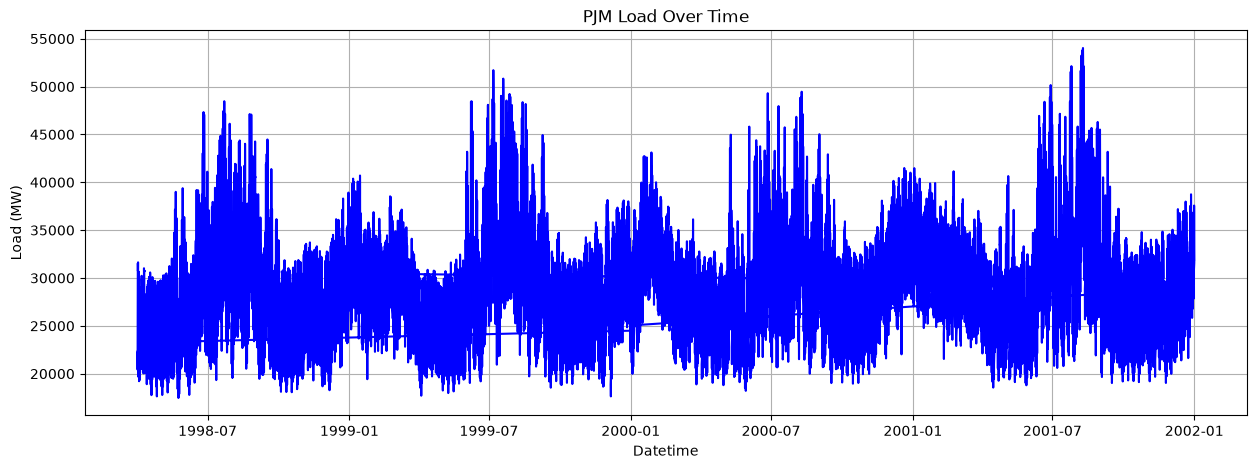

In [46]:
plt.figure(figsize=(15, 5))
plt.plot(df['Datetime'], df['PJM_Load_MW'], color='blue')
plt.xlabel('Datetime')
plt.ylabel('Load (MW)')
plt.title('PJM Load Over Time')
plt.grid(True)
plt.show()


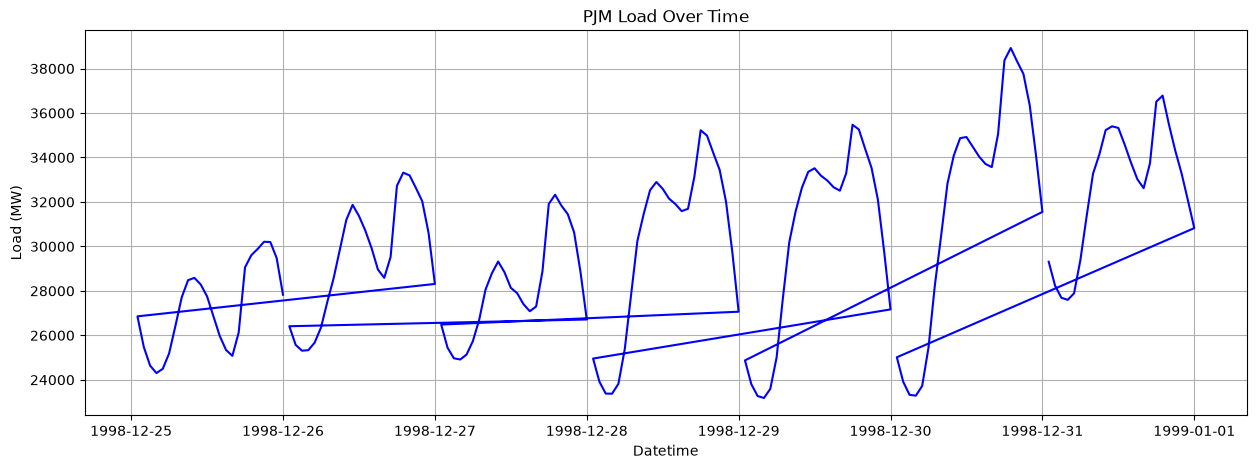

In [47]:
sample=df.iloc[:24*7]
plt.figure(figsize=(15, 5))
plt.plot(sample['Datetime'], sample['PJM_Load_MW'], color='blue')
plt.xlabel('Datetime')
plt.ylabel('Load (MW)')
plt.title('PJM Load Over Time')
plt.grid(True)
plt.show()  

In [48]:
print("start: ", df['Datetime'].min())
print("end: ", df['Datetime'].max())

start:  1998-04-01 01:00:00
end:  2002-01-01 00:00:00


In [49]:
time_diff = df['Datetime'].diff()
print(time_diff.value_counts().head(10))

Datetime
0 days 01:00:00      31517
-2 days +01:00:00     1367
0 days 02:00:00          8
729 days 01:00:00        2
638 days 01:00:00        1
Name: count, dtype: int64


In [50]:
df=df.sort_values(by='Datetime', ascending=True)
df=df.reset_index(drop=True)


In [51]:
df["PJM_Load_MW"].describe()


count    32896.000000
mean     29766.427408
std       5849.769954
min      17461.000000
25%      25473.000000
50%      29655.000000
75%      33073.250000
max      54030.000000
Name: PJM_Load_MW, dtype: float64

In [52]:
max_index = df['PJM_Load_MW'].idxmax()
print(df.loc[max_index])

Datetime       2001-08-09 15:00:00
PJM_Load_MW                54030.0
Name: 29431, dtype: object


In [53]:
min_index = df['PJM_Load_MW'].idxmin()
print(df.loc[min_index])


Datetime       1998-05-24 05:00:00
PJM_Load_MW                17461.0
Name: 1275, dtype: object


In [55]:
df["hour"] = df["Datetime"].dt.hour
df["day_of_week"] = df["Datetime"].dt.dayofweek
df["month"] = df["Datetime"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [59]:
df.head(5
        )   

,Datetime,PJM_Load_MW,hour,day_of_week,month,is_weekend
0,1998-04-01 01:00:00,22259.0,1,2,4,0
1,1998-04-01 02:00:00,21244.0,2,2,4,0
2,1998-04-01 03:00:00,20651.0,3,2,4,0
3,1998-04-01 04:00:00,20421.0,4,2,4,0
4,1998-04-01 05:00:00,20713.0,5,2,4,0


In [ ]:
hourly_demand = df.groupby('hour')['PJM_Load_MW'].mean()
print(hourly_demand)

